In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import os

from torch.utils.benchmark.examples.spectral_ops_fuzz_test import BENCHMARK_MAP

In [10]:
BENCHMARK_RESULTS_DIR = "."
Q_FLAIR_RESULTS_DIR = "../Results/Data_QNN"

# Load accuracy results

In [11]:
def line_to_dict(line: str):
    line = line.strip().split()
    return dict(zip(line[::2], line[1::2]))

def load(bench_folder, max_n_gate, acc_format_filename="ACC_classical_surrogate_{}.txt"):
    model_infos = []
    accuracy_dfs = []
    for n_gate in range(1, max_n_gate + 1):
        acc_filename = os.path.join(BENCHMARK_RESULTS_DIR, bench_folder, acc_format_filename.format(n_gate))
        # print first line:
        with open(acc_filename, 'r') as f:
            first_line = f.readline()
            model_infos.append(line_to_dict(first_line))
            accuracy_dicts = []
            for line in f:
                if line.strip() == "":
                    continue
                accuracy_dicts.append(line_to_dict(line))
            if len(accuracy_dicts) > 0:
                acc_df = pd.DataFrame(accuracy_dicts).apply(pd.to_numeric, errors='ignore')
                accuracy_dfs.append(acc_df)
    return model_infos, accuracy_dfs

def combine_accuracies(accuracy_dfs, max_col_name):
    results = []
    for n_gate, df in enumerate(accuracy_dfs):
        if df is None:
            continue
        max_row = df.loc[df[max_col_name].idxmax()]
        results.append({'n_gate': n_gate + 1, **max_row.to_dict()})
    aggregated_results = pd.DataFrame(results)
    return aggregated_results

# Visualize

In [69]:
def plot_classical_surrogate_acc(bench_folder, max_n_gate, max_col_name, ax=None, add_best_line=False, include_train_acc=False, data_set_color='blue'):
    model_infos, acc_dfs = load(bench_folder, max_n_gate=max_n_gate)
    comb_df = combine_accuracies(acc_dfs, max_col_name=max_col_name)
    if ax is None:
        ax = plt.gca()
    if include_train_acc:
        ax.plot(comb_df['n_gate'], 100 * comb_df['train_acc'], label='Classical Surrogate (Train)', color='grey', linestyle='--')
    ax.plot(comb_df['n_gate'], 100 * comb_df['val_acc'], label='Classical Surrogate', linestyle='--', color=data_set_color)
    if add_best_line:
        best_acc = comb_df['val_acc'].max()
        ax.axhline(100 * best_acc, linestyle=':', label='Best Accuracy', color='black')
    #ax.set_xlabel('number of gates')
    #ax.set_ylabel('accuracy [\\%]')
    #ax.legend()

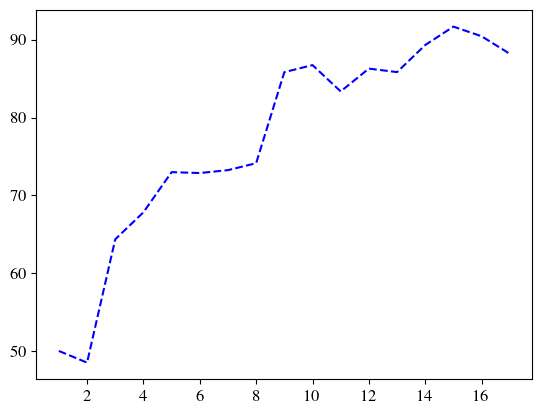

In [70]:
plot_classical_surrogate_acc("logLossBS", max_n_gate=125, max_col_name="train_acc")

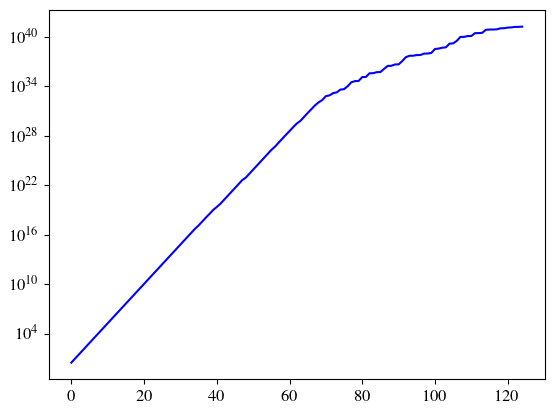

In [71]:
def plot_classical_surrogate_param_counts(bench_folder, max_n_gate, ax=None):
    if ax is None:
        ax = plt.gca()
    model_infos, _ = load(bench_folder, max_n_gate=max_n_gate)
    model_param_counts = [int(info['num_freqs'])*2 + 1 for info in model_infos]
    ax.plot(model_param_counts, label='Number of Parameters', color='blue')
    ax.set_yscale('log')
plot_classical_surrogate_param_counts(bench_folder="logLossBS", max_n_gate=125)

# Integrate in original plotting code

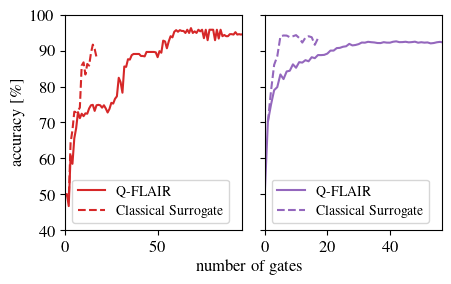

In [72]:
mpl.rcParams.update({'text.usetex':True,'font.size': 12, 'font.family': 'serif', 'font.serif': ['Times', 'Computer Modern']})

color = ['tab:red','orange','tab:purple','green']
fig = plt.figure(figsize=(11.69*0.4, 8.27*0.38))

# Initialize axes first so we can pass them to the function
ax1 = plt.subplot(1, 2, 1) # Left plot (BS)
ax2 = plt.subplot(1, 2, 2) # Right plot (MN)

# ==========================================
# RIGHT PLOT (ax2): logLossMN
# ==========================================

# 1. Q-FLAIR
name = 'logLossMN'
path_file_mn = os.path.join(Q_FLAIR_RESULTS_DIR, name, 'ACC_test.txt')
ACC0 = np.genfromtxt(path_file_mn, usecols=0, skip_header=1)
ACC1 = np.genfromtxt(path_file_mn, usecols=1, skip_header=1)
ACC0 = np.array([0.5, *ACC0])
ACC1 = np.array([0.5, *ACC1])
ACCaverOpt_mn = (ACC0 + ACC1) * 0.5
gatesOpt_mn = np.linspace(0, len(ACCaverOpt_mn)-1, len(ACCaverOpt_mn))

# Plot Q-FLAIR
curve1, = ax2.plot(gatesOpt_mn, ACCaverOpt_mn*100, '-', color=color[2], label='Q-FLAIR', fillstyle='none')
# 2. Classical Surrogate Benchmark (New)
# Using max_n_gate=56 based on your original ax2.set_xlim(0, 56+0.5)
plot_classical_surrogate_acc(
    name,
    max_n_gate=125,
    max_col_name="train_acc",
    ax=ax2,
    data_set_color=color[2],
)

# ==========================================
# LEFT PLOT (ax1): logLossBS
# ==========================================

# 1. Q-FLAIR (Optimized gate)
path_file_bs = os.path.join(Q_FLAIR_RESULTS_DIR, 'logLossBS', 'ACC_test.txt')
ACC0 = np.genfromtxt(path_file_bs, usecols=0, skip_header=1)
ACC1 = np.genfromtxt(path_file_bs, usecols=1, skip_header=1)
ACC0 = np.array([0.5, *ACC0])
ACC1 = np.array([0.5, *ACC1])
ACCaverOpt_bs = (ACC0 + ACC1) * 0.5
gatesOpt_bs = np.linspace(0, len(ACCaverOpt_bs)-1, len(ACCaverOpt_bs))

# Plot Q-FLAIR
curve2, = ax1.plot(gatesOpt_bs, ACCaverOpt_bs*100, '-', color=color[0], label='Q-FLAIR', fillstyle='none')

# 2. Classical Surrogate Benchmark (New)
# Using max_n_gate=95 based on your original ax1.set_xlim(0, 95+0.5)
plot_classical_surrogate_acc(
    "logLossBS",
    max_n_gate=95,
    max_col_name="train_acc",
    ax=ax1,
    data_set_color=color[0]
)

# ==========================================
# FORMATTING
# ==========================================

# Right Plot Limits (MN)
ax2.set_xlim(0, 56 + 0.5)
ax2.set_ylim(0.4 * 100, 1 * 100)
ax2.tick_params(labelleft=False) # Hide Y labels on the right plot
ax2.legend(fontsize='small')

# Left Plot Limits (BS)
ax1.set_xlim(0, 95 + 0.5)
ax1.set_ylim(0.4 * 100, 1 * 100)
ax1.set_ylabel(r'accuracy [\%]', fontsize='medium')
ax1.legend(fontsize='small')

# Global Labels
fig.supxlabel('number of gates', y=0.1, x=0.55, fontsize='medium')

plt.tight_layout()
plt.savefig('Acc_classical_surrogate_paper.pdf')
plt.show()